<a href="https://colab.research.google.com/github/JohnnyPoks/machine-learning-and-computer-vision/blob/main/MCF632_Dataset_Preprocessing_and_Feature_Engineering_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup

In [17]:
# Core libraries
import os
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_classif, mutual_info_regression

DATA_DIR = Path("/content")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def missing_summary(df):
    out = df.isna().sum().sort_values(ascending=False)
    out = out[out > 0]
    return out.to_frame("missing_count")

def plot_missing(df, title):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss) == 0:
        print("No missing values found.")
        return
    plt.figure(figsize=(10, 4))
    miss.plot(kind="bar")
    plt.title(title)
    plt.ylabel("Missing fraction")
    plt.tight_layout()
    plt.show()

def plot_top_features(feature_names, importances, title, top_n=15):
    s = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(9, 5))
    s.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    return s

def build_preprocessor(num_cols, cat_cols):
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", make_ohe())
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ])
    return preprocessor

2) Dataset 1 — Student Performance

Shape: (395, 36)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,avg_previous_grade,grade_growth,study_time_per_absence
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,5.5,1,0.285714
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,5.0,0,0.400000
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,7.5,1,0.181818
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,14.5,-1,1.000000
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,8.0,4,0.400000



Missing values:


,missing_count


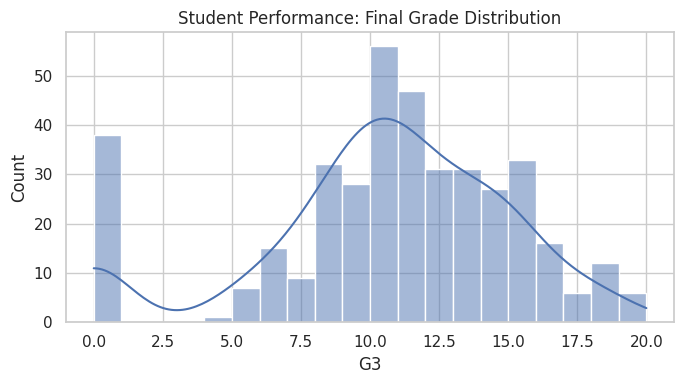

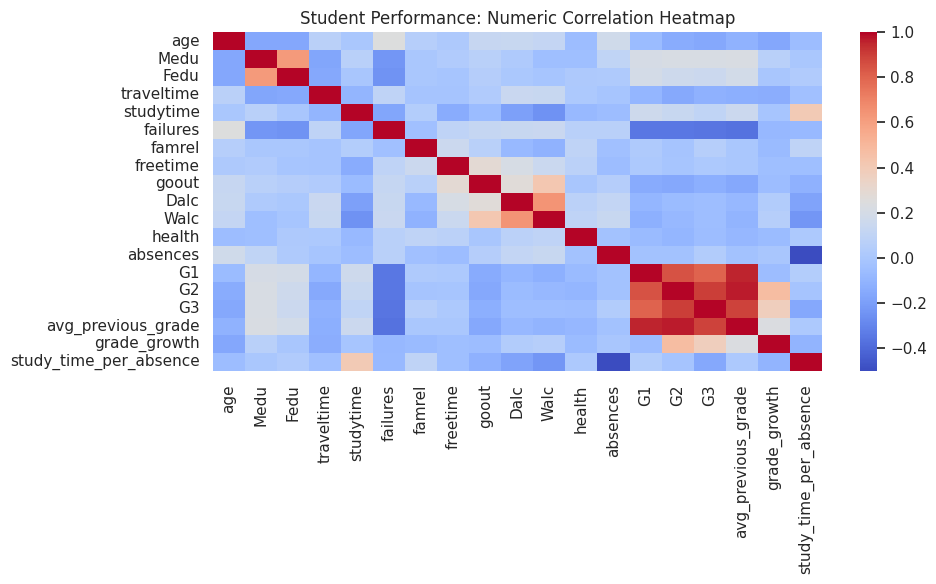

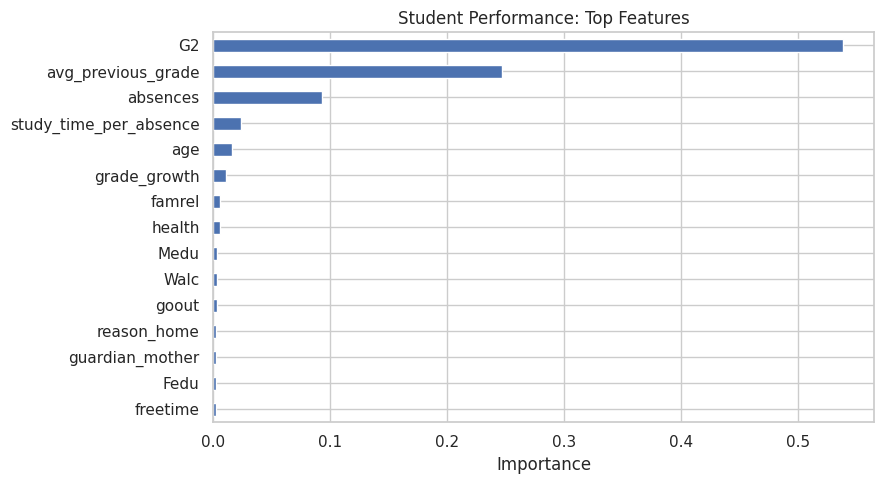

,importance
G2,0.537990
avg_previous_grade,0.246633
absences,0.093236
study_time_per_absence,0.024145
age,0.016188
grade_growth,0.010758
famrel,0.006058
health,0.005789
Medu,0.003782
Walc,0.003074


Processed shape: (395, 62)


In [18]:
# Load dataset directly from Download directory
student = pd.read_csv(DATA_DIR / "student-mat.csv", sep=";")

# Basic cleaning
student = student.drop_duplicates().reset_index(drop=True)

# Feature engineering: create new features
student["avg_previous_grade"] = student[["G1", "G2"]].mean(axis=1)
student["grade_growth"] = student["G2"] - student["G1"]
student["study_time_per_absence"] = student["studytime"] / (student["absences"] + 1)

# Target for this section
target = "G3"
X = student.drop(columns=[target])
y = student[target]

print("Shape:", student.shape)
display(student.head())
print("\nMissing values:")
display(missing_summary(student))

# Visualizations
plt.figure(figsize=(7, 4))
sns.histplot(student["G3"], bins=20, kde=True)
plt.title("Student Performance: Final Grade Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(student.select_dtypes(include=np.number).corr(), cmap="coolwarm", annot=False)
plt.title("Student Performance: Numeric Correlation Heatmap")
plt.tight_layout()
plt.show()

# Preprocess
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = build_preprocessor(num_cols, cat_cols)
X_processed = preprocessor.fit_transform(X)

# Feature names
cat_ohe = preprocessor.named_transformers_["cat"].named_steps["ohe"]
feature_names = np.r_[num_cols, cat_ohe.get_feature_names_out(cat_cols)]

# Feature selection / importance
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_processed, y)

top_student = plot_top_features(feature_names, model.feature_importances_,
                                "Student Performance: Top Features", top_n=15)
display(top_student.to_frame("importance"))

# Clean output dataframe
student_clean = pd.DataFrame(X_processed, columns=feature_names)
student_clean[target] = y.values
print("Processed shape:", student_clean.shape)

3) Dataset 2 — Titanic

Shape: (891, 15)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr



Missing values:


,missing_count
Cabin,687
Age,177


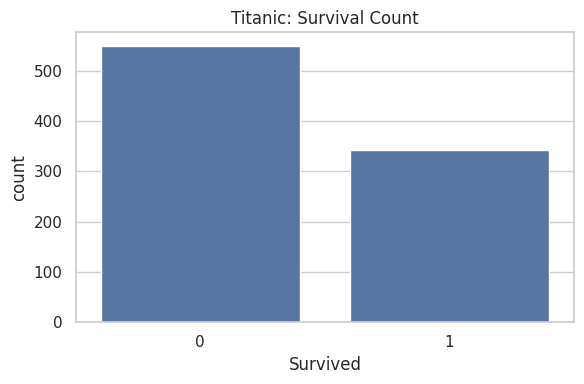

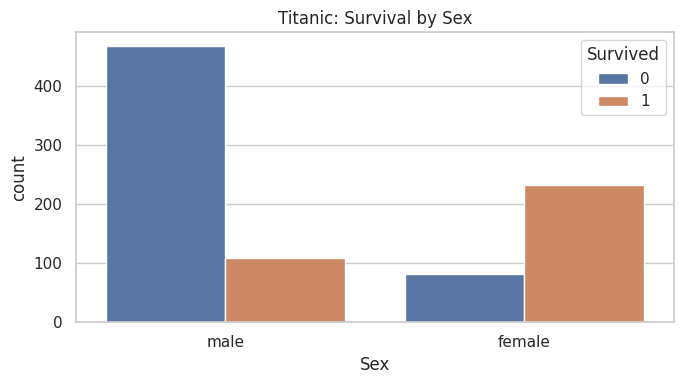

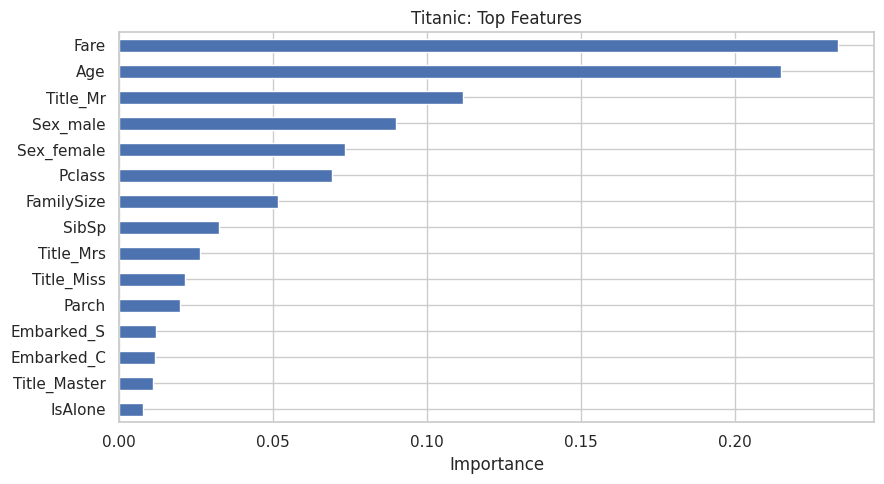

,importance
Fare,0.233542
Age,0.214882
Title_Mr,0.111584
Sex_male,0.089927
Sex_female,0.073293
Pclass,0.069257
FamilySize,0.051469
SibSp,0.032527
Title_Mrs,0.026428
Title_Miss,0.021520


Processed shape: (891, 18)


In [19]:
# Load dataset directly from Download directory
titanic = pd.read_csv(DATA_DIR / "titanic.csv")

# Cleaning
titanic = titanic.drop_duplicates().reset_index(drop=True)

# Feature engineering
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)
titanic["Title"] = titanic["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
titanic["Title"] = titanic["Title"].replace(
    ["Mlle", "Ms", "Mme", "Lady", "Countess", "Sir", "Jonkheer", "Don", "Dona", "Capt", "Col", "Major", "Rev", "Dr"],
    "Rare"
)

# Useful cleanup
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

# Target
target = "Survived"

# Drop columns that are not useful for this assignment
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
X = titanic.drop(columns=[target] + drop_cols)
y = titanic[target]

print("Shape:", titanic.shape)
display(titanic.head())
print("\nMissing values:")
display(missing_summary(titanic))

# Visualizations
plt.figure(figsize=(6, 4))
sns.countplot(data=titanic, x="Survived")
plt.title("Titanic: Survival Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(data=titanic, x="Sex", hue="Survived")
plt.title("Titanic: Survival by Sex")
plt.tight_layout()
plt.show()

# Preprocess
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = build_preprocessor(num_cols, cat_cols)
X_processed = preprocessor.fit_transform(X)

cat_ohe = preprocessor.named_transformers_["cat"].named_steps["ohe"]
feature_names = np.r_[num_cols, cat_ohe.get_feature_names_out(cat_cols)]

# Feature selection / importance
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_processed, y)

top_titanic = plot_top_features(feature_names, model.feature_importances_,
                                "Titanic: Top Features", top_n=15)
display(top_titanic.to_frame("importance"))

# Clean output dataframe
titanic_clean = pd.DataFrame(X_processed, columns=feature_names)
titanic_clean[target] = y.values
print("Processed shape:", titanic_clean.shape)

4) Dataset 3 — House Prices

Shape: (1460, 85)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodAge,TotalSF,TotalBathrooms
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,5,5,2566,3.5
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,31,31,2524,2.5
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,7,6,2706,3.5
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,91,36,2473,2.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,8,8,3343,3.5



Missing values:


,missing_count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageFinish,81
GarageQual,81


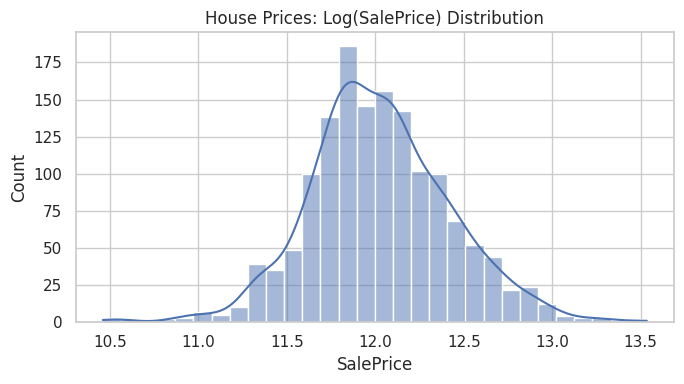

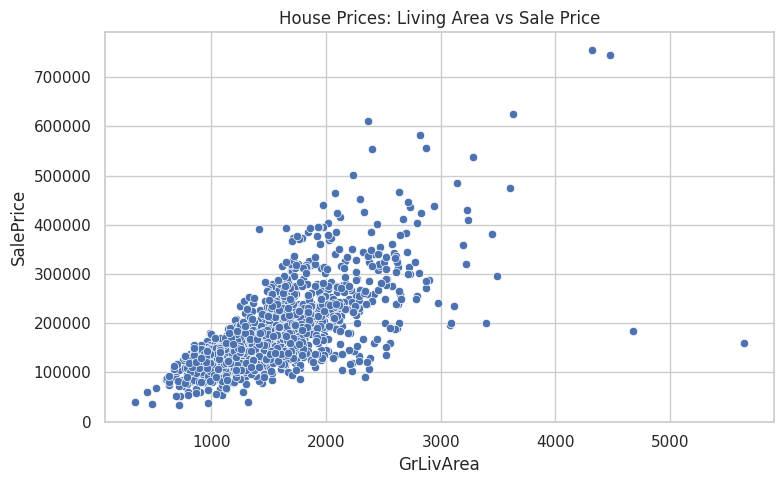

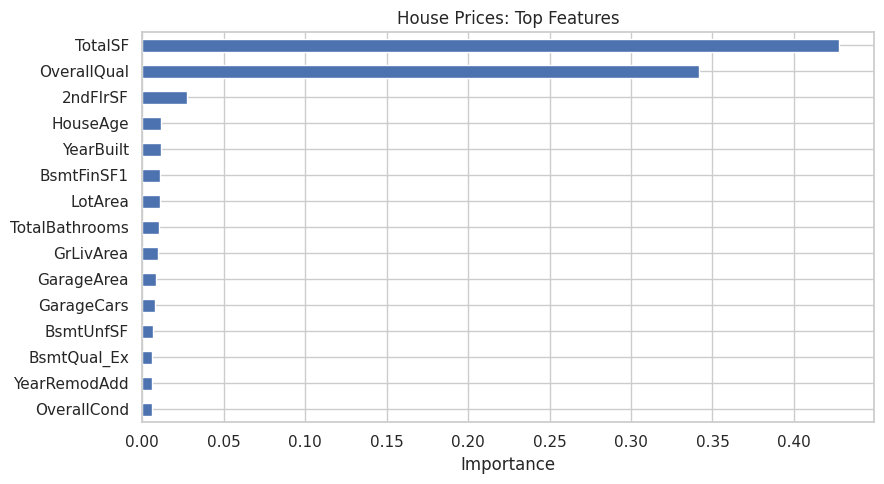

,importance
TotalSF,0.427713
OverallQual,0.341470
2ndFlrSF,0.027463
HouseAge,0.011809
YearBuilt,0.011326
BsmtFinSF1,0.011293
LotArea,0.011012
TotalBathrooms,0.010543
GrLivArea,0.009690
GarageArea,0.008313


Processed shape: (1460, 292)


In [21]:
# Load dataset directly from Download directory
house = pd.read_csv(DATA_DIR / "house_prices.csv")

# Cleaning
house = house.drop_duplicates().reset_index(drop=True)

# Feature engineering
house["HouseAge"] = house["YrSold"] - house["YearBuilt"]
house["RemodAge"] = house["YrSold"] - house["YearRemodAdd"]
house["TotalSF"] = house["TotalBsmtSF"] + house["1stFlrSF"] + house["2ndFlrSF"]
house["TotalBathrooms"] = (
    house["FullBath"] + 0.5 * house["HalfBath"] +
    house["BsmtFullBath"] + 0.5 * house["BsmtHalfBath"]
)

target = "SalePrice"
X = house.drop(columns=[target, "Id"])
y = house[target]

print("Shape:", house.shape)
display(house.head())
print("\nMissing values:")
display(missing_summary(house).head(20))

# Visualizations
plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(house["SalePrice"]), bins=30, kde=True)
plt.title("House Prices: Log(SalePrice) Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=house, x="GrLivArea", y="SalePrice")
plt.title("House Prices: Living Area vs Sale Price")
plt.tight_layout()
plt.show()

# Preprocess
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = build_preprocessor(num_cols, cat_cols)
X_processed = preprocessor.fit_transform(X)

cat_ohe = preprocessor.named_transformers_["cat"].named_steps["ohe"]
feature_names = np.r_[num_cols, cat_ohe.get_feature_names_out(cat_cols)]

# Feature selection / importance
model = RandomForestRegressor(n_estimators=250, random_state=42)
model.fit(X_processed, y)

top_house = plot_top_features(feature_names, model.feature_importances_,
                              "House Prices: Top Features", top_n=15)
display(top_house.to_frame("importance"))

# Clean output dataframe
house_clean = pd.DataFrame(X_processed, columns=feature_names)
house_clean[target] = y.values
print("Processed shape:", house_clean.shape)

5) Summary

In [23]:
print("Student Performance cleaned shape:", student_clean.shape)
print("Titanic cleaned shape:", titanic_clean.shape)
print("House Prices cleaned shape:", house_clean.shape)

print("\n Checklist:")
print("1. Cleaned data: done")
print("2. Missing values handled: done")
print("3. Categorical variables encoded: done")
print("4. Numerical features scaled: done")
print("5. New features created: done")
print("6. Important features selected: done")

Student Performance cleaned shape: (395, 62)
Titanic cleaned shape: (891, 18)
House Prices cleaned shape: (1460, 292)

 Checklist:
1. Cleaned data: done
2. Missing values handled: done
3. Categorical variables encoded: done
4. Numerical features scaled: done
5. New features created: done
6. Important features selected: done
